# Day 2 - 모델 개발 및 평가

Day 1에서 세운 모델 설계 전략을 코드로 옮기고, **Batch 1으로 학습 → Batch 2로 테스트**한 성능을 원논문(Severson et al., 2019, MAPE 9.1%)과 비교합니다. 함수는 Day 1 노트북(`day_1_jiwon.ipynb`)의 것을 그대로 가져오고, 바꾼 부분은 이유와 함께 표시합니다.

## 0. Day 1 전략에서 바뀐 점

Day 1 전략은 "세 배치를 합쳐 학습"을 전제로 했습니다. Day 2 과제는 **학습 = Batch 1, 테스트 = Batch 2**로 정해져 있어서 아래 다섯 가지를 다시 봤습니다.

| 항목 | Day 1 전략 | Day 2 | 이유 |
|---|---|---|---|
| 학습 데이터 | 세 배치 129셀 | **Batch 1만** | 과제 조건 |
| 검증 | 정책 GroupKFold + 배치 LOBO, 지표 RMSE · MAPE · 배치별 bias (3-2) | **Batch 1 안에서 정책 단위 CV + Hold-out**. 과제 포맷은 MAPE, RMSE · bias는 9절 보조 표 | 과제 조건. 같은 정책 셀이 train/valid에 나뉘면 누수 |
| 피처 선택 | 세 배치의 수명 상관이 같은 방향인 피처 | **Batch 1 학습 부분만으로 다시 확인** | Day 1 기준은 Batch 2·3의 **정답(수명)** 까지 봤음. Batch 2가 테스트가 된 지금은 시험지를 미리 본 것과 같음 |
| 전처리 | 스무딩 → 100사이클 자르기 | **100사이클 자르기 → 스무딩** | 가운데 정렬 rolling(11)이라 cycle 96~100 값이 101~105를 참조하고 있었음 |
| Batch 1 중도절단 셀 | I13에서 "제외를 기본, 포함과 비교"로 정했지만 3절 기준선(129셀)에는 포함된 채로 계산 | **I13대로 기본 제외, 7절에서 포함한 경우와 비교** | 10셀의 `cycle_life`가 실제 수명이 아니라 "기록이 끝난 사이클" (EDA 1-3) |

이 노트북의 순서는 아래와 같습니다.

1. 데이터 로드 → 2. 전처리 보완 → 3. 셀 단위 데이터셋 → 4. 데이터 분할 → 5. 피처 다시 고르기 → 6. 모델 비교 (Batch 1 지표만) → 7. Hold-out 안정성 → 8. 최종 모델 선택 → 9. **Batch 2 / Batch 3 평가 (여기서 처음으로 테스트를 봄)** → 10. 오류 분석 → 11. ESS 관점 해석과 한계

In [1]:
import logging
import re
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV, GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["font.family"] = ["AppleGothic", "Noto Sans CJK JP"]
plt.rcParams["axes.unicode_minus"] = False

SEED = 42            # 분할 · 모델 · 샘플링 모두 이 시드로 고정 (재현성)
DATA_DIR = Path("../archive")   # 원본 .mat은 저장소 루트의 archive/
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)
FILES = {
    "batch1": DATA_DIR / "2017-05-12_batchdata_updated_struct_errorcorrect.mat",   # 학습
    "batch2": DATA_DIR / "2018-02-20_batchdata_updated_struct_errorcorrect.mat",   # 테스트 (필수)
    "batch3": DATA_DIR / "2018-04-12_batchdata_updated_struct_errorcorrect.mat",   # 테스트 (추가)
}
EOL_Q = 0.88         # 공칭 1.1Ah의 80% = 수명 종료 기준
EARLY = 100          # 예측 시점: 2 ~ 100사이클 정보만 사용
PAPER_MAPE = 9.1     # 원논문 목표 성능 (Regression, MAPE)
BATCH_COLORS = {"batch1": "#2a78d6", "batch2": "#eb6834", "batch3": "#22a37a"}

## 1. 데이터 로드

Day 1 노트북의 `load_summary_df`, `load_delta_q`, `dq_features`, `parse_policy`를 그대로 씁니다.

In [2]:
# ---- Day 1 노트북에서 그대로 가져온 함수 ----
def mat_str(f, ref):
    """MATLAB char 배열(uint16) → str"""
    return "".join(chr(c) for c in f[ref][()].ravel())


def load_summary_df(path):
    dfs = []
    with h5py.File(path, "r") as f:
        batch = f["batch"]
        for i in range(batch["summary"].shape[0]):
            summary = f[batch["summary"][i, 0]]
            df = pd.DataFrame({k: summary[k][()].ravel() for k in summary.keys()})
            df.insert(0, "cell_id", i)
            df.insert(1, "policy", mat_str(f, batch["policy_readable"][i, 0]))
            df.insert(2, "cycle_life", f[batch["cycle_life"][i, 0]][()].item())
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)


def load_delta_q(path, cycle_a=100, cycle_b=10):
    """셀별 ΔQ(V) = Qdlin(cycle_a) - Qdlin(cycle_b).  Qdlin은 3.5~2.0V를 1000점으로 보간한 방전 용량"""
    with h5py.File(path, "r") as f:
        batch = f["batch"]
        V = f[batch["Vdlin"][0, 0]][()].ravel()
        dq = {}
        for i in range(batch["cycles"].shape[0]):
            cycles = f[batch["cycles"][i, 0]]
            q = lambda c: f[cycles["Qdlin"][c - 1, 0]][()].ravel()  # 인덱스 0 = 사이클 1
            dq[i] = q(cycle_a) - q(cycle_b)
    return V, pd.DataFrame(dq, index=V).T  # 행 = cell_id, 열 = 전압


def dq_features(dq):
    """ΔQ(V) 곡선 → 통계값 피처"""
    return pd.DataFrame({
        "log_var": np.log10(dq.var(axis=1)),
        "log_abs_min": np.log10(dq.min(axis=1).abs()),
        "log_abs_mean": np.log10(dq.mean(axis=1).abs()),
        "skew": stats.skew(dq, axis=1),
        "kurtosis": stats.kurtosis(dq, axis=1),
        "dq_at_2V": dq.iloc[:, -1],
    })


def parse_policy(policy):
    """'5.6C(26%)-4.5C-newstructure' → C1, Q1(전환 SOC %), C2.  VarCharge 등 형식이 다르면 NaN"""
    m = re.match(r"([\d.]+)C\((\d+)%\)-([\d.]+)C", policy)
    if m is None:
        return pd.Series({"C1": np.nan, "Q1": np.nan, "C2": np.nan})
    return pd.Series({"C1": float(m[1]), "Q1": float(m[2]), "C2": float(m[3])})


batches, dqs = {}, {}
for name, path in FILES.items():
    batches[name] = load_summary_df(path)
    V, dqs[name] = load_delta_q(path)
    print(f"{name}: {batches[name]['cell_id'].nunique()} cells, {len(batches[name]):,} rows")

batch1: 46 cells, 38,811 rows
batch2: 47 cells, 26,904 rows
batch3: 46 cells, 51,007 rows


## 2. 전처리 보완

### 2-1. 중도절단 셀 표시

EDA 1-3에서 Batch 1의 10셀이 EOL(0.88Ah)에 닿기 전에 기록이 끝난 것을 확인했습니다. 마지막 10사이클 용량 중앙값이 `EOL + 0.01`보다 크면 중도절단으로 표시합니다.

Batch 1이 유일한 학습 데이터라서 이 10셀(학습 데이터의 22%)의 정답이 틀리면 영향이 큽니다. 가이드라인에도 "데이터 품질 문제로 원논문에서도 제거된 셀이 있다"고 나와 있어서, **기본은 제외**하고 7절에서 포함한 경우와 비교합니다.

In [3]:
def flag_censored(df):
    """EOL(0.88Ah)에 닿기 전에 기록이 끝난 셀 → cycle_life가 실제 수명보다 짧게 기록됨"""
    d = df[(df["cycle"] > 1) & df["QDischarge"].between(0.5, 1.3)]
    q_end = d.groupby("cell_id")["QDischarge"].apply(lambda s: s.iloc[-10:].median())
    life = df.groupby("cell_id")["cycle_life"].first()
    return pd.DataFrame({"cycle_life": life, "q_end": q_end,
                         "censored": life.notna() & (q_end > EOL_Q + 0.01)})


cens = {name: flag_censored(df) for name, df in batches.items()}
for name, c in cens.items():
    print(f"{name}: 중도절단 {int(c['censored'].sum())}셀")
display(cens["batch1"][cens["batch1"]["censored"]].join(
    batches["batch1"].groupby("cell_id")["policy"].first()).round(3))

batch1: 중도절단 10셀
batch2: 중도절단 0셀
batch3: 중도절단 0셀


,cycle_life,q_end,censored,policy
cell_id,,,,
0,1190.0,1.027,True,3.6C(80%)-3.6C
1,1179.0,1.039,True,3.6C(80%)-3.6C
2,1177.0,1.044,True,3.6C(80%)-3.6C
3,1226.0,0.972,True,4C(80%)-4C
4,1227.0,1.022,True,4C(80%)-4C
8,879.0,0.972,True,5.4C(40%)-3.6C
10,906.0,0.963,True,5.4C(50%)-3C
12,902.0,0.917,True,5.4C(50%)-3.6C
13,897.0,0.927,True,5.4C(50%)-3.6C


### 2-2. `early_features`: 자르고 나서 스무딩

Day 1의 `early_features`는 `smooth_q`로 **전체 사이클**에 rolling median(11, 가운데 정렬)을 건 다음 100사이클로 잘랐습니다. 그러면 cycle 96~100의 값을 만들 때 cycle 101~105가 섞입니다. "100사이클까지만 보고 예측한다"는 조건을 지키려고 순서를 바꿨습니다. 나머지 계산은 Day 1과 같습니다.

In [4]:
def smooth_q_early(df):
    """Day 1 smooth_q와 같은 정리를 하되, 먼저 2~EARLY 사이클로 자른 뒤 그 안에서만 스무딩"""
    d = df[df["cycle"].between(2, EARLY)].copy()
    d.loc[~d["QDischarge"].between(0.5, 1.3), "QDischarge"] = np.nan
    d["Q_s"] = d.groupby("cell_id")["QDischarge"].transform(
        lambda s: s.rolling(11, center=True, min_periods=1).median())
    return d.dropna(subset=["Q_s"])


def early_features(df, smooth=smooth_q_early):
    """summary의 초기 100사이클 → 셀 단위 피처 (Day 1과 같은 계산, 스무딩 함수만 교체)"""
    d = smooth(df)
    d = d[d["cycle"] <= EARLY]
    rows = []
    for cid, g in d.groupby("cell_id"):
        c, q = g["cycle"].to_numpy(), g["Q_s"].to_numpy()
        last = g["cycle"] > EARLY - 10
        ir = g.loc[g["IR"] > 0, "IR"]
        t = g[["Tavg", "Tmax", "Tmin"]]
        t = t.where(t.ge(20) & t.le(50))
        ir = ir if len(ir) else pd.Series([np.nan])
        rows.append(dict(
            cell_id=cid,
            Q2=q[0], Q100=q[-1],
            Qmax_minus_Q2=q.max() - q[0],
            slope_2_100=np.polyfit(c, q, 1)[0] * 100,
            slope_91_100=np.polyfit(c[last], q[last], 1)[0] * 100,
            IR2=ir.iat[0], IR_min=ir.min(),
            IR_diff=ir.iat[-1] - ir.iat[0],
            Tavg_mean=t["Tavg"].mean(), Tmax_max=t["Tmax"].max(), Tmin_min=t["Tmin"].min(),
            chargetime_2_6=g.loc[g["cycle"] <= 6, "chargetime"].mean(),
        ))
    return pd.DataFrame(rows).set_index("cell_id")


# Day 1 방식(스무딩 → 자르기)과 비교: 어떤 피처가 얼마나 달라지는지
def smooth_q_day1(df):
    d = df[df["cycle"] > 1].copy()
    d.loc[~d["QDischarge"].between(0.5, 1.3), "QDischarge"] = np.nan
    d["Q_s"] = d.groupby("cell_id")["QDischarge"].transform(
        lambda s: s.rolling(11, center=True, min_periods=1).median())
    return d.dropna(subset=["Q_s"])


old = early_features(batches["batch1"], smooth=smooth_q_day1)
new = early_features(batches["batch1"])
diff = ((new - old).abs() / old.abs().replace(0, np.nan)).mean() * 100
print("Batch 1, Day 1 방식 대비 평균 변화율(%) - 0이 아닌 피처만")
print(diff[diff > 0.01].round(2).to_string())

Batch 1, Day 1 방식 대비 평균 변화율(%) - 0이 아닌 피처만
slope_2_100      3.13
slope_91_100    31.49


## 3. 셀 단위 데이터셋

Day 1의 `cell_dataset`과 같은 구조입니다. 여기에 중도절단 여부와 **`protocol`(newstructure 표기를 뗀 충전 조건)** 을 붙입니다. `protocol`은 데이터를 나눌 때 그룹 단위로 씁니다.

In [5]:
def cell_dataset(df, dq, name):
    cells = df.groupby("cell_id").agg(policy=("policy", "first"), cycle_life=("cycle_life", "first"))
    cells = cells.join(cells["policy"].apply(parse_policy))
    cells["newstructure"] = cells["policy"].str.contains("newstructure").astype(int)
    cells["protocol"] = cells["policy"].str.replace("-newstructure", "", regex=False)
    cells["censored"] = cens[name]["censored"]
    out = cells.join(early_features(df)).join(dq_features(dq))
    out.insert(0, "batch", name)
    out.index = name + "_" + out.index.astype(str)
    return out


data_all = pd.concat([cell_dataset(df, dqs[name], name) for name, df in batches.items()])
data = data_all[data_all["cycle_life"].notna()].copy()   # cycle_life 결측 10셀 제외 (Day 1 데이터 점검)
data["log_life"] = np.log10(data["cycle_life"])           # Target (Day 1 전략 2절)
FEATURES = ["log_var", "log_abs_min", "log_abs_mean", "skew", "kurtosis", "dq_at_2V",
            "Q2", "Q100", "Qmax_minus_Q2", "slope_2_100", "slope_91_100",
            "IR2", "IR_min", "IR_diff", "Tavg_mean", "Tmax_max", "Tmin_min", "chargetime_2_6",
            "C1", "Q1", "C2"]
print(f"모델링 대상 {len(data)} / {len(data_all)}셀 | 후보 피처 {len(FEATURES)}개")
display(data.groupby("batch").agg(cells=("cycle_life", "size"), censored=("censored", "sum"),
                                  life_median=("cycle_life", "median"), protocols=("protocol", "nunique")))

모델링 대상 129 / 139셀 | 후보 피처 21개


,cells,censored,life_median,protocols
batch,,,,
batch1,46,10,858.5,23
batch2,39,0,472.0,9
batch3,44,0,1005.5,8


## 4. 데이터 분할

```
Batch 1 (중도절단 제외 36셀)
 ├─ Hold-out : 충전 protocol 단위로 20%를 통째로 떼어냄          → Valid
 └─ 나머지   : protocol GroupKFold(5)                             → Train CV, 하이퍼파라미터 튜닝
최종 모델 = Batch 1 전체(36셀)로 다시 학습 → Batch 2 (Test), Batch 3 (추가 Test) 각 한 번
```

- **protocol 단위로 나누는 이유**: Batch 1은 같은 충전 조건 셀이 2개씩 있습니다. 한 셀은 학습, 다른 셀은 검증에 들어가면 모델이 "이 충전 조건이면 수명이 이 정도"를 외운 것이 성능으로 잡힙니다. 가이드라인이 Valid를 Hold-out으로 두라고 한 이유와 같습니다.
- **Batch 2·3는 9절 전까지 정답을 보지 않습니다.** 모델·피처 선택은 Batch 1 지표로만 합니다.

In [6]:
b1 = data[(data["batch"] == "batch1") & ~data["censored"]]
b1_censored = data[(data["batch"] == "batch1") & data["censored"]]
test2 = data[data["batch"] == "batch2"]
test3 = data[data["batch"] == "batch3"]


def split_b1(seed=SEED, include_censored=False):
    """Batch 1 → (train, hold). 중도절단 셀은 넣더라도 train 쪽에만 (정답이 부정확해서 평가에는 쓰지 않음)"""
    tr, ho = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed).split(b1, groups=b1["protocol"]))
    train, hold = b1.iloc[tr], b1.iloc[ho]
    if include_censored:
        train = pd.concat([train, b1_censored])
    return train, hold


train, hold = split_b1()
print(f"Batch 1 train {len(train)}셀 ({train['protocol'].nunique()} protocols) | hold-out {len(hold)}셀 ({hold['protocol'].nunique()} protocols)")
print("hold-out protocols:", sorted(hold["protocol"].unique()))
print("train ∩ hold protocol:", set(train["protocol"]) & set(hold["protocol"]) or "없음 (누수 없음)")
print(f"수명 범위  train {train['cycle_life'].min():.0f}~{train['cycle_life'].max():.0f} | hold {hold['cycle_life'].min():.0f}~{hold['cycle_life'].max():.0f}"
      f" | Batch 2 {test2['cycle_life'].min():.0f}~{test2['cycle_life'].max():.0f} | Batch 3 {test3['cycle_life'].min():.0f}~{test3['cycle_life'].max():.0f}")

Batch 1 train 29셀 (16 protocols) | hold-out 7셀 (4 protocols)
hold-out protocols: ['4.4C(80%)-4.4C', '4.8C(80%)-4.8C', '7C(40%)-3.6C', '8C(15%)-3.6C']
train ∩ hold protocol: 없음 (누수 없음)
수명 범위  train 534~1054 | hold 617~1074 | Batch 2 392~1186 | Batch 3 541~1935


## 5. 피처 다시 고르기 (Batch 1 train만 사용)

Day 1에서 고른 4개(`log_var`, `kurtosis`, `Q1`, `slope_91_100`)를 Batch 1 train에서만 다시 확인합니다.

기준은 Day 1과 같은 생각을 이어갑니다.
1. **관련성**: train에서 |r(log10 수명)| ≥ 0.3
2. **이식성**: 테스트 배치의 **입력값(X) 분포만** 보고, 학습과 너무 다르거나(KS > 0.75) 거의 상수인(표준편차 비율 < 0.25) 피처는 뺍니다. 정답(수명)은 보지 않습니다. 평균 충전 속도가 모두 같도록 설계된 Batch 2·3 때문에 Day 1에서 "배치마다 부호가 바뀐다"고 본 `chargetime_2_6` 같은 피처를, 이번에는 정답 없이 걸러내는 방법입니다.
3. **중복**: 이미 고른 피처와 |r| ≥ 0.7이면 뺍니다.

In [7]:
DAY1_SELECTED = ["log_var", "kurtosis", "Q1", "slope_91_100"]
DAY1_POOLED_R = {"log_var": -0.89, "kurtosis": 0.32, "Q1": 0.18, "slope_91_100": 0.17}   # Day 1 노트북 결과 (세 배치 합침)

r_train = train[FEATURES].corrwith(train["log_life"])
rows = []
for f in FEATURES:
    rec = {"r (B1 train)": r_train[f]}
    for name, t in [("B2", test2), ("B3", test3)]:
        rec[f"KS {name}"] = stats.ks_2samp(train[f].dropna(), t[f].dropna()).statistic
        rec[f"std비 {name}"] = t[f].std() / train[f].std()
    rows.append(pd.Series(rec, name=f))
sel = pd.DataFrame(rows)
sel["relevant"] = sel["r (B1 train)"].abs() >= 0.3
sel["transfer_ok"] = (sel[["KS B2", "KS B3"]].max(axis=1) <= 0.75) & (sel[["std비 B2", "std비 B3"]].min(axis=1) >= 0.25)

B1_SELECTED = []
for f in sel[sel["relevant"] & sel["transfer_ok"]].sort_values("r (B1 train)", key=abs, ascending=False).index:
    if all(abs(train[f].corr(train[s])) < 0.7 for s in B1_SELECTED):
        B1_SELECTED.append(f)


def status(f):
    if f in B1_SELECTED: return "선택"
    if not sel.at[f, "relevant"]: return "약함"
    if not sel.at[f, "transfer_ok"]: return "테스트 배치에서 분포 이동/상수"
    return "중복"


sel["판정"] = [status(f) for f in sel.index]
sel = sel.sort_values("r (B1 train)", key=abs, ascending=False)
display(sel.drop(columns=["relevant", "transfer_ok"]).round(2))

print("\nDay 1 선택 피처: 세 배치 합친 r  →  Batch 1 train r")
for f in DAY1_SELECTED:
    print(f"  {f:13s} {DAY1_POOLED_R[f]:+.2f}  →  {r_train[f]:+.2f}   ({sel.at[f, '판정']})")
print("\nBatch 1 train으로 다시 고른 피처:", B1_SELECTED)

,r (B1 train),KS B2,std비 B2,KS B3,std비 B3,판정
log_var,-0.81,0.58,1.77,0.70,1.31,선택
log_abs_min,-0.79,0.58,1.72,0.68,1.64,중복
log_abs_mean,-0.74,0.55,1.61,0.67,2.07,중복
dq_at_2V,0.71,0.54,1.73,0.55,0.97,중복
slope_2_100,0.63,0.49,1.99,0.21,1.37,중복
slope_91_100,0.62,0.67,3.24,0.45,1.16,선택
skew,-0.52,0.43,1.46,0.20,2.76,중복
chargetime_2_6,0.52,0.66,0.08,0.73,0.43,테스트 배치에서 분포 이동/상수
C2,-0.49,0.88,1.09,0.89,0.93,테스트 배치에서 분포 이동/상수
IR_min,0.46,0.24,1.73,0.89,1.62,테스트 배치에서 분포 이동/상수



Day 1 선택 피처: 세 배치 합친 r  →  Batch 1 train r
  log_var       -0.89  →  -0.81   (선택)
  kurtosis      +0.32  →  -0.16   (약함)
  Q1            +0.18  →  -0.21   (약함)
  slope_91_100  +0.17  →  +0.62   (선택)

Batch 1 train으로 다시 고른 피처: ['log_var', 'slope_91_100', 'C1']


Day 1의 4개 중 `kurtosis`와 `Q1`은 깨끗한 Batch 1 train에서는 상관이 거의 없거나 부호가 반대로 나왔습니다. Day 1에서는 세 배치를 합쳐서 봤기 때문에 생긴 착시로 보입니다. 그래서 피처 묶음을 하나로 정하지 않고 네 가지를 같은 조건에서 비교합니다.

| 피처 묶음 | 내용 | 출처 |
|---|---|---|
| `logvar_only` | `log_var` 하나 | 원논문 Variance model, Day 1 기준선 |
| `day1_selected` | `log_var`, `kurtosis`, `Q1`, `slope_91_100` | Day 1 전략 |
| `b1_selected` | 위 표에서 Batch 1 train으로 고른 피처 | Day 2 재선택 |
| `paper_discharge` | `log_abs_min`, `log_var`, `skew`, `kurtosis`, `Q2`, `Qmax_minus_Q2` | 원논문 Discharge model (ΔQ 통계 4개 + 방전 용량 2개) |

In [8]:
FEATURE_SETS = {
    "logvar_only": ["log_var"],
    "day1_selected": DAY1_SELECTED,
    "b1_selected": B1_SELECTED,
    "paper_discharge": ["log_abs_min", "log_var", "skew", "kurtosis", "Q2", "Qmax_minus_Q2"],
}
for k, v in FEATURE_SETS.items():
    print(f"{k:16s} {v}")

logvar_only      ['log_var']
day1_selected    ['log_var', 'kurtosis', 'Q1', 'slope_91_100']
b1_selected      ['log_var', 'slope_91_100', 'C1']
paper_discharge  ['log_abs_min', 'log_var', 'skew', 'kurtosis', 'Q2', 'Qmax_minus_Q2']


## 6. 모델 비교 (Batch 1 지표만)

Day 1 전략 3-3의 후보를 그대로 씁니다. 모든 모델은 `Pipeline(결측 대체 → StandardScaler → 모델)`이라 스케일러가 fold마다 학습 부분에서만 fit 됩니다.

| 모델 | 이유 (Day 1 전략) |
|---|---|
| Dummy(평균) | 기준선 |
| Linear | `log_var`와 log 수명이 선형 (EDA 3·5) |
| ElasticNet | 주력. 셀이 적고 선형, L1이 약한 피처를 0으로 |
| GPR | 소표본 + 비선형 + 불확실성 |
| RandomForest / GradientBoosting | 상호작용. 얕게 제한. 학습 범위 밖 예측이 약한지 확인용 |

- **Train (Batch 1 CV)**: train 29셀에서 protocol GroupKFold(5)로 예측한 MAPE. 하이퍼파라미터는 각 fold 안에서 다시 GroupKFold로 고릅니다(nested).
- **Valid (Batch 1 Hold-out)**: train 전체로 튜닝·학습 → hold-out 7셀 예측.
- 타깃은 `log10(cycle_life)`로 학습하고, 평가는 `10 ** ŷ`로 되돌려서 사이클 단위 MAPE로 합니다.

In [9]:
def pipe(est):
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler()), ("model", est)])


MODELS = {
    "Dummy": (pipe(DummyRegressor()), {}),
    "Linear": (pipe(LinearRegression()), {}),
    "ElasticNet": (pipe(ElasticNet(max_iter=50000)),
                   {"model__alpha": [0.001, 0.003, 0.01, 0.03, 0.1], "model__l1_ratio": [0.1, 0.5, 0.9]}),
    # 노이즈 상한(0.5)을 둬서 "평균만 예측"으로 무너지지 않게 함 (처음엔 기본 커널로 Dummy와 같은 결과가 나왔음)
    "GPR": (pipe(GaussianProcessRegressor(
        kernel=ConstantKernel(1.0, (1e-2, 1e2)) * RBF(2.0, (0.3, 30.0)) + WhiteKernel(0.1, (1e-3, 0.5)),
        normalize_y=True, n_restarts_optimizer=3, random_state=SEED)), {}),
    "RandomForest": (pipe(RandomForestRegressor(n_estimators=200, random_state=SEED)),
                     {"model__max_depth": [2, 3], "model__min_samples_leaf": [2, 4]}),
    "GradientBoosting": (pipe(GradientBoostingRegressor(subsample=0.8, learning_rate=0.05, random_state=SEED)),
                         {"model__max_depth": [1, 2], "model__n_estimators": [100, 300]}),
}


def fit(est, grid, df, feats):
    """grid가 있으면 protocol GroupKFold 안에서만 튜닝"""
    if not grid:
        return clone(est).fit(df[feats], df["log_life"])
    gs = GridSearchCV(clone(est), grid, cv=GroupKFold(min(5, df["protocol"].nunique())),
                      scoring="neg_mean_absolute_error")
    gs.fit(df[feats], df["log_life"], groups=df["protocol"])
    return gs.best_estimator_


def predict(model, df, feats):
    return pd.Series(10 ** model.predict(df[feats]), index=df.index)


def mape(df, pred):
    m = ~df["censored"]                       # 중도절단 셀은 정답이 부정확하므로 평가에서 제외
    return 100 * np.mean(np.abs(pred[m] - df.loc[m, "cycle_life"]) / df.loc[m, "cycle_life"])


def cv_predict(est, grid, df, feats, k=5):
    pred = pd.Series(index=df.index, dtype=float)
    for tr, va in GroupKFold(k).split(df, groups=df["protocol"]):
        m = fit(est, grid, df.iloc[tr], feats)
        pred.iloc[va] = predict(m, df.iloc[va], feats)
    return pred


rows = []
for fs, feats in FEATURE_SETS.items():
    for name, (est, grid) in MODELS.items():
        cv = cv_predict(est, grid, train, feats)
        ho = predict(fit(est, grid, train, feats), hold, feats)
        rows.append(dict(feature_set=fs, model=name, train_cv=mape(train, cv), valid=mape(hold, ho)))
compare = pd.DataFrame(rows)
print("Train (Batch 1 CV) MAPE %")
display(compare.pivot(index="model", columns="feature_set", values="train_cv").round(2))
print("Valid (Batch 1 Hold-out) MAPE %")
display(compare.pivot(index="model", columns="feature_set", values="valid").round(2))

Train (Batch 1 CV) MAPE %


feature_set,b1_selected,day1_selected,logvar_only,paper_discharge
model,,,,
Dummy,15.10,15.10,15.10,15.10
ElasticNet,8.82,9.57,8.85,7.07
GPR,10.25,11.50,9.13,6.71
GradientBoosting,10.62,10.90,10.15,11.01
Linear,8.13,10.32,8.85,7.24
RandomForest,10.11,9.96,11.06,10.42


Valid (Batch 1 Hold-out) MAPE %


feature_set,b1_selected,day1_selected,logvar_only,paper_discharge
model,,,,
Dummy,22.23,22.23,22.23,22.23
ElasticNet,16.00,11.57,8.48,6.26
GPR,15.89,14.47,10.98,6.98
GradientBoosting,14.91,14.20,8.80,7.98
Linear,16.04,10.95,8.47,6.43
RandomForest,10.48,10.27,8.57,10.41


## 7. Hold-out 안정성과 중도절단 포함 여부

Hold-out이 7셀뿐이라 셀 하나만 바뀌어도 MAPE가 크게 흔들립니다. Train CV 상위 6개 조합을 골라 **분할 seed 10개**로 Hold-out을 반복하고, 같은 실험을 **중도절단 10셀을 학습에 넣은 경우**와 비교합니다. 여기서도 Batch 2·3는 쓰지 않습니다.

In [10]:
top = compare[compare["model"] != "Dummy"].nsmallest(6, "train_cv")[["feature_set", "model"]].values.tolist()
rows = []
for inc in [False, True]:
    for fs, name in top:
        est, grid = MODELS[name]
        for seed in range(10):
            tr, ho = split_b1(seed=seed, include_censored=inc)
            rows.append(dict(censored="포함" if inc else "제외", feature_set=fs, model=name,
                             valid=mape(ho, predict(fit(est, grid, tr, FEATURE_SETS[fs]), ho, FEATURE_SETS[fs]))))
stab = pd.DataFrame(rows).groupby(["censored", "feature_set", "model"])["valid"].agg(["mean", "std"]).round(2)
display(stab)

mean   std
censored feature_set     model                  
제외       b1_selected     ElasticNet  11.24  3.09
                         Linear      11.17  3.93
         logvar_only     ElasticNet   9.57  2.21
         paper_discharge ElasticNet   6.63  0.96
                         GPR          6.29  1.30
                         Linear       7.13  1.61
포함       b1_selected     ElasticNet  13.22  2.68
                         Linear      12.22  2.94
         logvar_only     ElasticNet  12.34  2.44
         paper_discharge ElasticNet   8.58  1.79
                         GPR          6.99  1.12
                         Linear       7.96  1.49

## 8. 최종 모델 선택

테스트를 보기 전에 규칙을 먼저 정했습니다.

1. 점수 = (Train CV MAPE + Hold-out 10회 평균 MAPE) / 2, 중도절단 **제외** 버전 기준
2. 최저 점수와 0.5%p 안쪽이면 같은 수준으로 보고, **선형 계열(Linear/ElasticNet)을 우선**합니다. Day 1 EDA(I3)에서 Batch 2·3 수명이 Batch 1 범위 밖에 있어 외삽이 필요하다고 봤기 때문입니다. 트리는 학습 범위 밖 값을 만들 수 없고, GPR(RBF)은 범위 밖에서 평균으로 돌아가는 성질이 있습니다.

In [11]:
score = compare.set_index(["feature_set", "model"])["train_cv"].to_frame()
score["holdout10"] = stab.loc["제외"]["mean"]
score = score.dropna()
score["score"] = (score["train_cv"] + score["holdout10"]) / 2
best = score["score"].min()
tie = score[score["score"] <= best + 0.5].copy()
tie["linear"] = tie.index.get_level_values("model").isin(["Linear", "ElasticNet"])
FINAL_FS, FINAL_MODEL = tie.sort_values(["linear", "score"], ascending=[False, True]).index[0]
FINAL_FEATS = FEATURE_SETS[FINAL_FS]
display(score.sort_values("score").round(2))
print(f"최종: {FINAL_FS} + {FINAL_MODEL}  →  피처 {FINAL_FEATS}")

train_cv  holdout10  score
feature_set     model                                 
paper_discharge GPR             6.71       6.29   6.50
                ElasticNet      7.07       6.63   6.85
                Linear          7.24       7.13   7.19
logvar_only     ElasticNet      8.85       9.57   9.21
b1_selected     Linear          8.13      11.17   9.65
                ElasticNet      8.82      11.24  10.03

최종: paper_discharge + ElasticNet  →  피처 ['log_abs_min', 'log_var', 'skew', 'kurtosis', 'Q2', 'Qmax_minus_Q2']


## 9. 최종 평가

최종 모델을 Batch 1 전체(중도절단 제외 36셀)로 다시 튜닝·학습하고, **Batch 2와 Batch 3를 각각 한 번** 예측합니다.

Gap은 MAPE가 낮을수록 좋은 지표라서 **"뒤 단계 − 앞 단계"** 로 계산합니다. 그러면 가이드라인의 (+) 해석(과적합 의심, 일반화 저하 의심)과 방향이 맞습니다.

In [12]:
est, grid = MODELS[FINAL_MODEL]
cv_final = cv_predict(est, grid, train, FINAL_FEATS)
m_train = fit(est, grid, train, FINAL_FEATS)
m_final = fit(est, grid, b1, FINAL_FEATS)            # Batch 1 전체로 재학습

pred = pd.concat([
    pd.DataFrame({"set": "B1 CV", "pred": cv_final}),
    pd.DataFrame({"set": "B1 Hold-out", "pred": predict(m_train, hold, FINAL_FEATS)}),
    pd.DataFrame({"set": "Batch 2", "pred": predict(m_final, test2, FINAL_FEATS)}),
    pd.DataFrame({"set": "Batch 3", "pred": predict(m_final, test3, FINAL_FEATS)}),
]).join(data[["batch", "policy", "protocol", "newstructure", "cycle_life", "censored"]])
pred["ape"] = 100 * (pred["pred"] - pred["cycle_life"]).abs() / pred["cycle_life"]
pred["signed"] = 100 * (pred["pred"] - pred["cycle_life"]) / pred["cycle_life"]   # (+) = 수명을 길게 예측

M = pred.groupby("set")["ape"].mean()
tr_, va_, t2, t3 = M["B1 CV"], M["B1 Hold-out"], M["Batch 2"], M["Batch 3"]
report_b2 = pd.DataFrame([
    ("Train (Batch 1 CV)", tr_, f"protocol GroupKFold(5), nested 튜닝, {len(train)}셀"),
    ("Valid (Batch 1 Hold-out)", va_, f"protocol 단위 20%, {len(hold)}셀 (seed 10회 평균 {stab.loc[('제외', FINAL_FS, FINAL_MODEL), 'mean']:.2f})"),
    ("Test (Batch 2)", t2, f"{len(test2)}셀"),
    ("Gap (Train-Valid)", va_ - tr_, "Valid − Train, (+) : 과적합 의심"),
    ("Gap (Valid-Test)", t2 - va_, "Test − Valid, (+) : 배치간 일반화 저하 의심"),
    ("Gap (Target-Test)", t2 - PAPER_MAPE, f"Test − Target, Target : 원논문 {PAPER_MAPE}%"),
], columns=["구분", "MAPE (%)", "비고"])
report_b3 = pd.concat([report_b2, pd.DataFrame([
    ("Test (Batch 3)", t3, f"{len(test3)}셀"),
    ("Gap (Batch2-Batch3)", t2 - t3, "Batch 2 − Batch 3"),
    ("Gap (Target-Test)", t3 - PAPER_MAPE, f"Batch 3 기준, 원논문 {PAPER_MAPE}% 비교"),
], columns=report_b2.columns)], ignore_index=True)
report_b3.round(2).to_csv(RESULTS / "model_performance.csv", index=False)
pred.to_csv(RESULTS / "predictions.csv")
display(report_b3.round(2))

,구분,MAPE (%),비고
0,Train (Batch 1 CV),7.07,"protocol GroupKFold(5), nested 튜닝, 29셀"
1,Valid (Batch 1 Hold-out),6.26,"protocol 단위 20%, 7셀 (seed 10회 평균 6.63)"
2,Test (Batch 2),25.79,39셀
3,Gap (Train-Valid),-0.81,"Valid − Train, (+) : 과적합 의심"
4,Gap (Valid-Test),19.53,"Test − Valid, (+) : 배치간 일반화 저하 의심"
5,Gap (Target-Test),16.69,"Test − Target, Target : 원논문 9.1%"
6,Test (Batch 3),14.67,44셀
7,Gap (Batch2-Batch3),11.12,Batch 2 − Batch 3
8,Gap (Target-Test),5.57,"Batch 3 기준, 원논문 9.1% 비교"


### 보조 지표: Day 1 전략 기준 (RMSE · bias, 기준선 대비)

Day 1 전략 3-2에서 지표를 RMSE(사이클) · MAPE · 배치별 bias로, 3-3에서 `log_var` 단일 선형회귀를 **모든 모델이 넘어야 할 기준선**으로 정했습니다. 과제 포맷(MAPE)과 별도로 같은 세트에서 이 두 가지를 같이 봅니다. 기준선은 테스트를 보기 전에 정해 둔 모델이라 비교에 써도 공정합니다.

In [13]:
def run_sets(est, grid, feats):
    """최종 모델과 같은 절차: B1 CV / Hold-out(train으로 학습) / Batch 1 전체 재학습 → Batch 2·3"""
    m_tr, m_all = fit(est, grid, train, feats), fit(est, grid, b1, feats)
    return {"B1 CV": cv_predict(est, grid, train, feats), "B1 Hold-out": predict(m_tr, hold, feats),
            "Batch 2": predict(m_all, test2, feats), "Batch 3": predict(m_all, test3, feats)}


def set_metrics(preds):
    rows = {}
    for s, p in preds.items():
        y = data.loc[p.index, "cycle_life"]
        rows[s] = {"RMSE": np.sqrt(((p - y) ** 2).mean()), "MAPE %": 100 * ((p - y).abs() / y).mean(),
                   "bias %": 100 * ((p - y) / y).mean()}
    return pd.DataFrame(rows).T


final_sets = {s: g["pred"] for s, g in pred.groupby("set", sort=False)}
metrics_tbl = pd.concat({f"최종 ({FINAL_FS} + {FINAL_MODEL})": set_metrics(final_sets),
                         "기준선 (log_var 선형)": set_metrics(run_sets(*MODELS["Linear"], ["log_var"]))})
metrics_tbl.round(2).to_csv(RESULTS / "metrics_by_set.csv")
display(metrics_tbl.round(2))

RMSE  MAPE %  bias %
최종 (paper_discharge + ElasticNet) B1 CV         72.36    7.07   -0.92
                                  B1 Hold-out   61.80    6.26    0.69
                                  Batch 2      174.18   25.79   25.20
                                  Batch 3      318.15   14.67  -10.16
기준선 (log_var 선형)                  B1 CV         91.45    8.85    0.28
                                  B1 Hold-out   85.68    8.47   -2.04
                                  Batch 2      163.13   28.56   28.14
                                  Batch 3      230.40   12.81    1.58

### Gap 해석

- **Gap (Train-Valid)**: 음수 또는 0에 가까우면 Batch 1 안에서는 과적합이 아닙니다.
- **Gap (Valid-Test)**: 크게 (+)입니다. Batch 1 안에서는 원논문 수준까지 맞히는데 Batch 2로 넘어가면 무너집니다. 다음 절에서 원인을 나눠 봅니다.
- **Gap (Target-Test)**: 원논문의 9.1%는 논문의 학습·테스트 배치 구성에서 나온 숫자입니다. 이번 과제의 Batch 2(`2018-02-20`)는 평균 충전 속도가 모두 4.8C로 같도록 설계됐고 `newstructure` 셀이 섞인, Batch 1과 조건이 다른 배치입니다 (EDA 1·4).
- **기준선 대비 (보조 표)**: Batch 1에서는 최종 모델이 기준선(`log_var` 선형)보다 확실히 낫고 (CV MAPE 7.07 vs 8.85, RMSE 72 vs 91), Batch 2 MAPE도 조금 낮습니다 (25.79 vs 28.56). 하지만 Batch 2 RMSE(174 vs 163)와 Batch 3 전체(MAPE 14.67 vs 12.81, RMSE 318 vs 230)는 기준선이 더 낫습니다. 피처를 늘린 이득이 Batch 1 안에서만 나타난 셈이라, 추가 피처(`Q2`, `Qmax_minus_Q2` 등)가 Batch 1에 맞춰졌을 가능성이 있습니다. Gap (Batch2-Batch3)과 함께 10절에서 원인을 나눠 봅니다.

## 10. 오류 분석

### 10-1. 예측 vs 실제

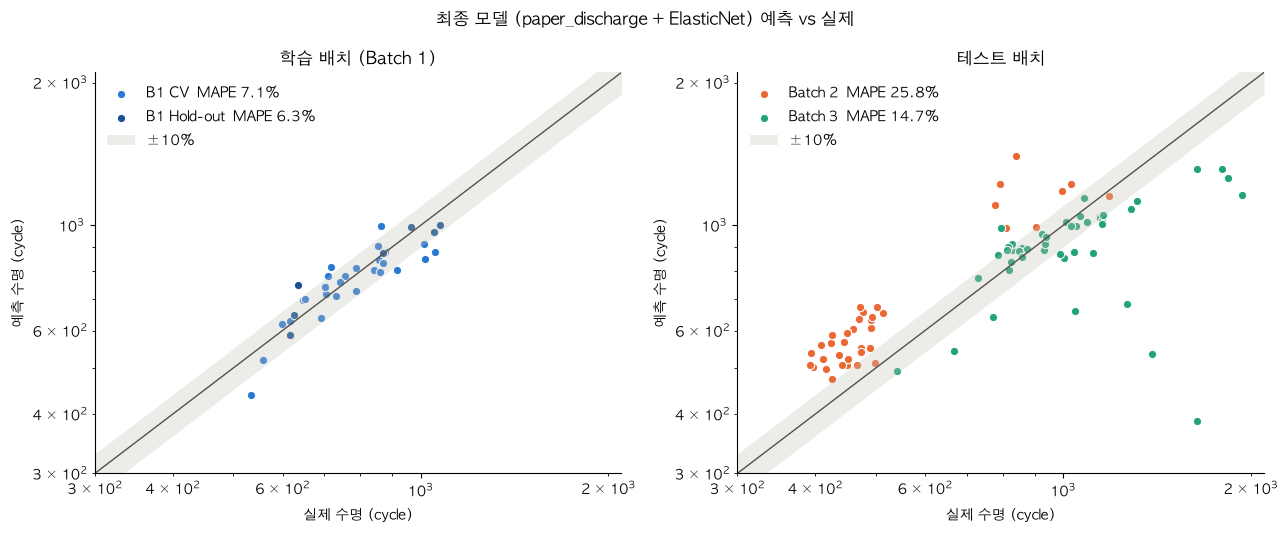

In [14]:
SET_COLORS = {"B1 CV": "#2a78d6", "B1 Hold-out": "#184f95", "Batch 2": "#eb6834", "Batch 3": "#22a37a"}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
lim = [300, 2100]
for ax, sets, title in [(axes[0], ["B1 CV", "B1 Hold-out"], "학습 배치 (Batch 1)"), (axes[1], ["Batch 2", "Batch 3"], "테스트 배치")]:
    for s in sets:
        t = pred[(pred["set"] == s) & ~pred["censored"]]
        ax.scatter(t["cycle_life"], t["pred"], s=36, color=SET_COLORS[s], edgecolor="white", linewidth=0.8,
                   label=f"{s}  MAPE {t['ape'].mean():.1f}%")
    ax.plot(lim, lim, color="#52514e", linewidth=1)
    ax.fill_between(lim, [v * 0.9 for v in lim], [v * 1.1 for v in lim], color="#c3c2b7", alpha=0.3, linewidth=0, label="±10%")
    ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel="실제 수명 (cycle)", ylabel="예측 수명 (cycle)", title=title)
    ax.legend(frameon=False, loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"최종 모델 ({FINAL_FS} + {FINAL_MODEL}) 예측 vs 실제", fontweight="bold")
plt.tight_layout()
plt.show()

### 10-2. 어디서 틀렸나: 그룹별 오차와 방향

부호 있는 오차 `(예측 − 실제) / 실제`를 같이 봅니다. (+)면 수명을 길게 예측한 것입니다.

,cells,life_median,pred_median,MAPE,bias
group,,,,,
Batch 2 newstructure,9,904.0,1151.8,27.0,24.5
Batch 2 기존 구조,30,451.0,555.7,25.4,25.4
Batch 3 (전부 newstructure),44,1005.5,897.0,14.7,-10.2


가장 크게 틀린 셀 Top 5


,policy,cycle_life,pred,signed
cell_id,,,,
batch2_44,5.2C(58%)-4C-newstructure,841.0,1401.0,67.0
batch2_9,5.6C(26%)-4.5C-newstructure,791.0,1223.0,55.0
batch2_16,4.8C(80%)-4.8C,472.0,674.0,43.0
batch2_7,4.8C(80%)-4.8C-newstructure,777.0,1103.0,42.0
batch2_31,5.6C(26%)-4.5C,425.0,587.0,38.0


,policy,cycle_life,pred,signed
cell_id,,,,
batch3_42,4.8C(80%)-4.8C-newstructure,1642.0,388.0,-76.0
batch3_37,4.8C(80%)-4.8C-newstructure,1390.0,535.0,-61.0
batch3_2,5.6C(19%)-4.6C-newstructure,1267.0,681.0,-46.0
batch3_38,5C(67%)-4C-newstructure,1935.0,1161.0,-40.0
batch3_43,5C(67%)-4C-newstructure,1046.0,660.0,-37.0


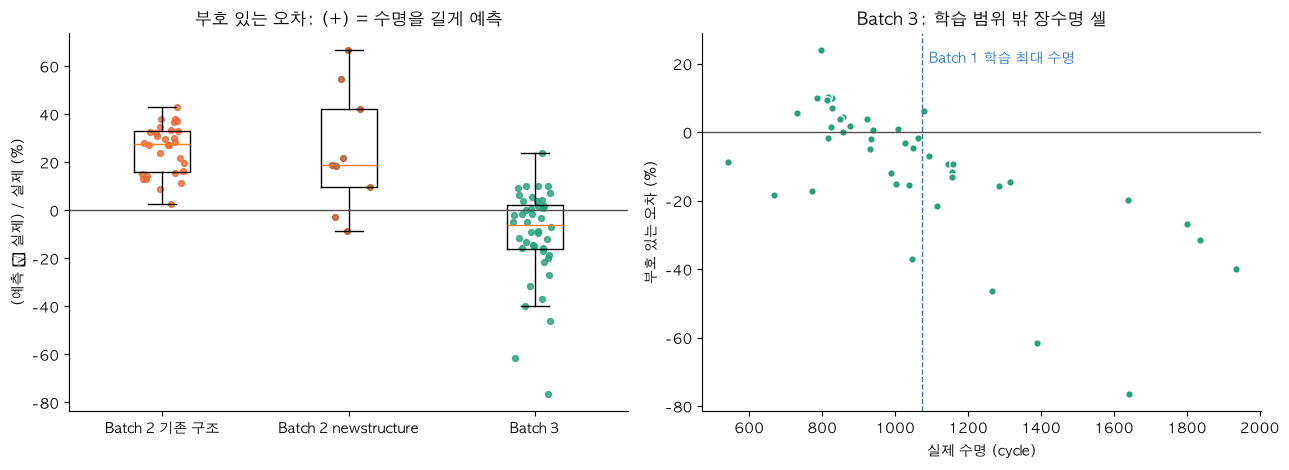

In [15]:
t = pred[pred["set"].isin(["Batch 2", "Batch 3"])].copy()
t["group"] = np.where(t["set"] == "Batch 3", "Batch 3 (전부 newstructure)",
                      np.where(t["newstructure"] == 1, "Batch 2 newstructure", "Batch 2 기존 구조"))
breakdown = t.groupby("group").agg(cells=("cycle_life", "size"), life_median=("cycle_life", "median"),
                                   pred_median=("pred", "median"), MAPE=("ape", "mean"), bias=("signed", "mean"))
display(breakdown.round(1))

print("가장 크게 틀린 셀 Top 5")
for s in ["Batch 2", "Batch 3"]:
    display(pred[pred["set"] == s].nlargest(5, "ape")[["policy", "cycle_life", "pred", "signed"]].round(0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
order = ["Batch 2 기존 구조", "Batch 2 newstructure", "Batch 3 (전부 newstructure)"]
groups = [t.loc[t["group"] == g, "signed"] for g in order]
ax1.boxplot(groups, tick_labels=[g.replace(" (전부 newstructure)", "") for g in order], showfliers=False)
rng = np.random.default_rng(SEED)
for i, (g, color) in enumerate(zip(groups, ["#eb6834", "#b8542a", "#22a37a"])):
    ax1.scatter(np.full(len(g), i + 1) + rng.uniform(-0.12, 0.12, len(g)), g, s=18, color=color, alpha=0.8)
ax1.axhline(0, color="#52514e", linewidth=1)
ax1.set(ylabel="(예측 − 실제) / 실제 (%)", title="부호 있는 오차: (+) = 수명을 길게 예측")
b3 = t[t["set"] == "Batch 3"]
ax2.scatter(b3["cycle_life"], b3["signed"], s=30, color="#22a37a", edgecolor="white")
ax2.axvline(b1["cycle_life"].max(), color="#2a78d6", linestyle="--", linewidth=1)
ax2.text(b1["cycle_life"].max() + 20, b3["signed"].max(), "Batch 1 학습 최대 수명", color="#2a78d6", va="top")
ax2.axhline(0, color="#52514e", linewidth=1)
ax2.set(xlabel="실제 수명 (cycle)", ylabel="부호 있는 오차 (%)", title="Batch 3: 학습 범위 밖 장수명 셀")
for a in (ax1, ax2):
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

- **Batch 2**: 기존 구조 셀(30개)과 newstructure 셀(9개) 모두 평균 약 **+25%** 길게 예측했습니다. newstructure 때문만은 아니고, Batch 2 전체가 같은 ΔQ 값에서도 Batch 1보다 수명이 짧은 배치라는 뜻입니다. Day 1 EDA(I12)에서 "B1으로 맞춘 직선에 대보면 B2가 약 24% 아래에 있다"고 본 것과 같은 크기입니다.
- **Batch 3**: 평균은 −10%로 짧게 예측했고, 특히 Batch 1 최대 수명(1,074)보다 긴 셀에서 크게 틀렸습니다(최대 −76%). 학습 범위 밖 외삽 문제(I3)와 아래 10-4의 곡선 왜곡이 겹친 결과로 보입니다.

### 10-3. Batch 2 오차는 "배치 기준선 이동"인가? (진단 실험, 최종 성능 아님)

Batch 2는 거의 모든 셀을 비슷한 비율로 길게 예측했습니다. 이게 피처가 틀려서인지, 배치 전체의 기준선이 옮겨가서인지 확인하려고 **테스트 셀 5개의 실제 수명만 안다고 가정**하고 log 공간에서 평균 오프셋만 보정해 봤습니다(200회 반복). 테스트 정답을 쓰는 실험이라 최종 성능 표에는 넣지 않고, 원인 진단과 ESS 적용 방법을 생각하는 데만 씁니다.

In [16]:
def offset_probe(s, k=5, reps=200):
    q = pred[pred["set"] == s]
    rng = np.random.default_rng(SEED)
    res = []
    for _ in range(reps):
        idx = rng.choice(len(q), k, replace=False)
        cal, rest = q.iloc[idx], q.drop(q.index[idx])
        off = np.median(np.log10(cal["cycle_life"]) - np.log10(cal["pred"]))
        res.append(100 * np.mean(np.abs(rest["pred"] * 10 ** off - rest["cycle_life"]) / rest["cycle_life"]))
    return np.mean(res), np.std(res)


for s in ["Batch 2", "Batch 3"]:
    m, sd = offset_probe(s)
    print(f"{s}: 보정 전 MAPE {M[s]:.1f}%  →  셀 5개로 오프셋 보정 후 {m:.1f} ± {sd:.1f}%")

Batch 2: 보정 전 MAPE 25.8%  →  셀 5개로 오프셋 보정 후 10.3 ± 1.6%


Batch 3: 보정 전 MAPE 14.7%  →  셀 5개로 오프셋 보정 후 16.8 ± 3.9%


- **Batch 2**는 셀 5개로 오프셋만 맞춰도 25.8% → 약 10%로 내려갑니다. 오차 대부분이 "배치 전체의 기준선 이동"이고, 셀 사이의 순서(어느 셀이 더 오래 가는지)는 모델이 대체로 맞히고 있다는 뜻입니다.
- **Batch 3**는 같은 보정을 하면 오히려 나빠집니다. Batch 3 오차는 배치 전체가 한쪽으로 쏠린 게 아니라 **일부 셀만 크게 틀린** 형태라서, 원인이 다릅니다.

### 10-4. Batch 3: ΔQ 곡선 앞쪽의 봉우리

가이드라인에 "충전 커브 시작 시점이 배치별로 달라 `Qdlin`을 단순 비교하면 왜곡된다"는 설명이 있습니다. Batch 3에서 가장 크게 틀린 셀의 ΔQ 곡선을 Batch 3 전체와 같이 그려 봅니다.

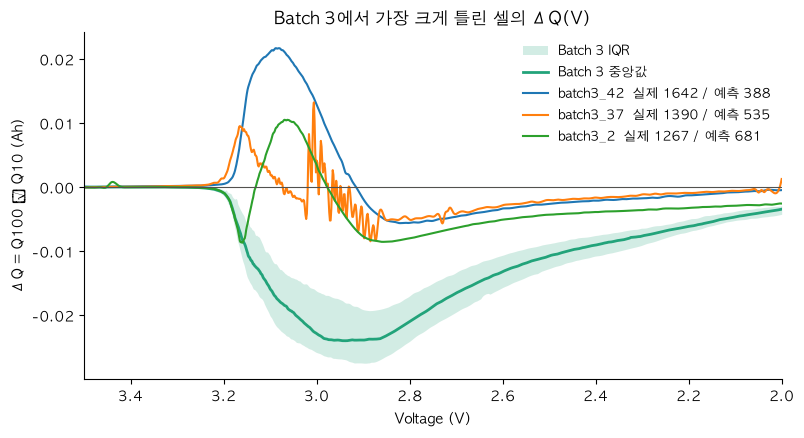

In [17]:
worst = pred[pred["set"] == "Batch 3"].nlargest(3, "ape").index
fig, ax = plt.subplots(figsize=(9, 4.5))
dq3 = dqs["batch3"]
ax.fill_between(V, dq3.quantile(0.25), dq3.quantile(0.75), color="#22a37a", alpha=0.2, linewidth=0, label="Batch 3 IQR")
ax.plot(V, dq3.median(), color="#22a37a", linewidth=2, label="Batch 3 중앙값")
for cid in worst:
    i = int(cid.split("_")[1])
    ax.plot(V, dq3.loc[i], linewidth=1.5,
            label=f"{cid}  실제 {pred.at[cid, 'cycle_life']:.0f} / 예측 {pred.at[cid, 'pred']:.0f}")
ax.axhline(0, color="#52514e", linewidth=0.8)
ax.set(xlim=(3.5, 2.0), xlabel="Voltage (V)", ylabel="ΔQ = Q100 − Q10 (Ah)", title="Batch 3에서 가장 크게 틀린 셀의 ΔQ(V)")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

가장 크게 틀린 Batch 3 셀들은 3.2 ~ 2.9V 구간에서 ΔQ가 **0보다 위로 솟는 봉우리**가 있었습니다. 100사이클의 용량이 10사이클보다 오히려 큰 구간이 생긴 것으로, 가이드라인이 말한 "충전 커브 시작 시점이 배치별로 달라 `Qdlin`을 단순 비교하면 생기는 왜곡"으로 보입니다.

`log_var`(분산)는 위로 솟든 아래로 꺼지든 크게 흔들리면 값이 커지기 때문에, 이 셀들을 "많이 열화된 셀 = 단수명"으로 읽었습니다. 실제로 열화를 나타내는 아래쪽 골은 Batch 3 중앙값보다 훨씬 얕아서, 장수명 셀이 맞습니다.

### 10-5. 모델이 본 것: 계수

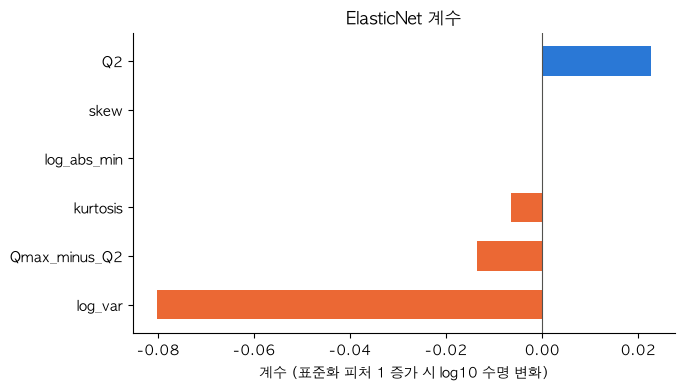

log_var         -0.0802
Qmax_minus_Q2   -0.0136
kurtosis        -0.0064
log_abs_min     -0.0000
skew             0.0000
Q2               0.0226


In [18]:
if FINAL_MODEL in ["Linear", "ElasticNet"]:
    coef = pd.Series(m_final.named_steps["model"].coef_, index=FINAL_FEATS).sort_values()
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(coef) + 1.2))
    ax.barh(coef.index, coef.values, color=["#2a78d6" if v > 0 else "#eb6834" for v in coef.values], height=0.6)
    ax.axvline(0, color="#52514e", linewidth=0.8)
    ax.set(xlabel="계수 (표준화 피처 1 증가 시 log10 수명 변화)", title=f"{FINAL_MODEL} 계수")
    ax.spines[["top", "right"]].set_visible(False)
    plt.show()
    print(coef.round(4).to_string())

### 10-6. 사후 개선 실험: 봉우리에 덜 민감한 피처

10-4를 보고 나서 한 실험이라 **최종 성능 표는 바꾸지 않고** 따로 기록합니다. 테스트 결과를 본 뒤 모델을 고치면 그 테스트 점수는 더 이상 공정한 평가가 아니기 때문입니다.

가설: 분산(`log_var`)을 빼고 골의 깊이(`log_abs_min`) 쪽에 맡기면, 봉우리 때문에 생긴 오차가 줄어든다. 판단 순서는 똑같이 **Batch 1 지표를 먼저** 보고, Batch 1에서 나빠지지 않을 때만 테스트를 봅니다.

In [19]:
NO_VAR = [f for f in FINAL_FEATS if f != "log_var"]
rows = []
for label, feats in [("최종 (log_var 포함)", FINAL_FEATS), ("log_var 제외", NO_VAR)]:
    cv = cv_predict(est, grid, train, feats)
    ho10 = np.mean([mape(h, predict(fit(est, grid, t, feats), h, feats)) for t, h in [split_b1(s) for s in range(10)]])
    mf = fit(est, grid, b1, feats)
    rows.append(dict(features=label, train_cv=mape(train, cv), holdout10=ho10,
                     test_B2=mape(test2, predict(mf, test2, feats)), test_B3=mape(test3, predict(mf, test3, feats))))
display(pd.DataFrame(rows).set_index("features").round(2))

,train_cv,holdout10,test_B2,test_B3
features,,,,
최종 (log_var 포함),7.07,6.63,25.79,14.67
log_var 제외,7.08,6.78,25.61,11.27


Batch 1 지표는 거의 같은데 Batch 3 오차가 줄어들면, 가설이 맞다는 근거가 됩니다. 다만 이 결과는 Batch 3를 본 뒤에 나온 아이디어라, 다음 버전에서 새 배치로 다시 확인해야 하는 **후보 개선안**으로 남겨둡니다. 근본적으로는 피처를 고치기보다 배치마다 다른 `Qdlin` 시작점을 맞춰주는 전처리(곡선 정렬)가 필요해 보입니다.

## 11. ESS 관점 해석과 한계

### 활용 방안
- **조기 수명 예측 → 교체 계획**: 초기 100사이클(전체 수명의 약 5~25%) 데이터만으로 수명을 추정해, 교체 비용이 CAPEX의 30~40%인 ESS에서 셀 교체 시점과 예산을 미리 잡을 수 있습니다. Batch 1과 같은 조건에서는 MAPE 6~7% 수준이라 충분히 쓸 만합니다.
- **입고 셀 선별**: 같은 로트 안에서 수명이 짧을 셀을 초기에 골라 팩 구성에서 빼거나 다른 용도로 돌릴 수 있습니다.
- **새 로트·새 조건 적용 시 보정**: Batch 2처럼 조건이 다른 배치에서는 오차가 배치 전체가 한쪽으로 쏠리는 형태였습니다. 새 로트를 들일 때 일부 셀을 끝까지 시험해 기준선만 보정하는 운영 방식(10-3)을 생각할 수 있습니다.

### 한계
- **배치 간 일반화**: 학습 배치와 충전 설계·셀 구조가 다른 배치에서는 오차가 크게 늘었습니다. 실제 ESS 셀은 실험실보다 훨씬 다양한 조건을 겪습니다.
- **실험 조건과 실제 운영의 차이**: 이 데이터는 급속충전(3.6~8C) + 4C 방전의 가속 시험입니다. 실제 ESS는 대부분 1C 이하 저율, 부분 충방전(SOC 구간 운전), 계절별 온도 변화를 겪으므로 그대로 적용할 수 없습니다.
- **학습 데이터 규모**: Batch 1은 중도절단을 빼면 36셀입니다. Hold-out이 7셀이라 한 셀에 따라 MAPE가 크게 흔들렸습니다(7절).
- **장수명 쪽 정보 부족**: 학습 최대 수명이 1,074사이클이라 그보다 긴 셀은 외삽에 의존합니다.

### 실제 배포를 위해 필요한 것
- 실제 운영 조건(저율, 부분 충방전, 온도 변화) 데이터로 재학습과 Live Test
- 새 로트·새 조건마다 일부 셀로 기준선을 보정하는 절차, 또는 여러 배치를 학습에 넣는 구조
- Data Drift 모니터링: 입력 피처(특히 ΔQ 통계) 분포가 학습 때와 달라지면 경고하고 재보정

## 12. 정리

| 항목 | 내용 |
|---|---|
| 태스크 / Target | Regression, `log10(cycle_life)` → 사이클 단위 MAPE로 평가 |
| 분할 | Batch 1 protocol 단위 Hold-out 20% + protocol GroupKFold(5) / Test = Batch 2, Batch 3 |
| 전처리 보완 | 100사이클로 자른 뒤 스무딩, Batch 1 중도절단 10셀 학습 제외 |
| 피처 | 6절 비교 후 8절 규칙으로 선택 (위 출력 참고) |
| 결과 | `results/model_performance.csv` (과제 포맷), `results/metrics_by_set.csv` (RMSE · bias, 기준선 대비) |